In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy import signal
import time

In [ ]:
# =========================
# IMAGE
# =========================
def create_image():
    img = np.zeros((256,256), dtype=np.uint8)
    cv2.rectangle(img,(30,30),(100,100),200,-1)
    cv2.circle(img,(180,80),40,150,-1)
    cv2.line(img,(50,180),(200,180),100,3)
    cv2.putText(img,'TEST',(90,150),
                cv2.FONT_HERSHEY_SIMPLEX,1,180,2)
    return img

# =========================
# PSF
# =========================
def motion_psf(length, angle):
    psf = np.zeros((length,length))
    c = length//2
    a = np.deg2rad(angle)
    x1 = int(c - (length/2)*np.cos(a))
    y1 = int(c - (length/2)*np.sin(a))
    x2 = int(c + (length/2)*np.cos(a))
    y2 = int(c + (length/2)*np.sin(a))
    cv2.line(psf,(x1,y1),(x2,y2),1,1)
    return psf/np.sum(psf)

# =========================
# NOISE
# =========================
def gaussian_noise(img, sigma=20):
    return np.clip(img + np.random.normal(0,sigma,img.shape),0,255).astype(np.uint8)

def salt_pepper(img, prob=0.05):
    noisy = img.copy()
    num = int(img.size*prob/2)
    coords = [np.random.randint(0,i,num) for i in img.shape]
    noisy[coords[0],coords[1]] = 255
    coords = [np.random.randint(0,i,num) for i in img.shape]
    noisy[coords[0],coords[1]] = 0
    return noisy

# =========================
# FILTER
# =========================
def inverse_filter(img, psf, eps=1e-3):
    G = np.fft.fft2(img)
    psf_p = np.zeros_like(img)
    psf_p[:psf.shape[0], :psf.shape[1]] = psf
    H = np.fft.fft2(np.fft.ifftshift(psf_p))
    F = G/(H+eps)
    return np.clip(np.abs(np.fft.ifft2(F)),0,255).astype(np.uint8)

def wiener_filter(img, psf, K=0.01):
    G = np.fft.fft2(img)
    psf_p = np.zeros_like(img)
    psf_p[:psf.shape[0], :psf.shape[1]] = psf
    H = np.fft.fft2(np.fft.ifftshift(psf_p))
    W = np.conj(H)/(np.abs(H)**2 + K)
    F = G*W
    return np.clip(np.abs(np.fft.ifft2(F)),0,255).astype(np.uint8)

def richardson_lucy(img, psf, iter=10):
    img = img.astype(float)
    est = img.copy()
    psf_flip = np.flip(psf)
    for i in range(iter):
        conv = cv2.filter2D(est,-1,psf)
        conv[conv==0]=1e-8
        est *= cv2.filter2D(img/conv,-1,psf_flip)
    return np.clip(est,0,255).astype(np.uint8)

# =========================
# METRICS
# =========================
def mse(a,b): return np.mean((a-b)**2)

def psnr(a,b):
    m = mse(a,b)
    return 10*np.log10(255**2/m) if m>0 else float('inf')

def ssim(a,b):
    C1=(0.01*255)**2
    C2=(0.03*255)**2
    a=a.astype(float); b=b.astype(float)
    mu1=cv2.GaussianBlur(a,(11,11),1.5)
    mu2=cv2.GaussianBlur(b,(11,11),1.5)
    s1=cv2.GaussianBlur(a*a,(11,11),1.5)-mu1**2
    s2=cv2.GaussianBlur(b*b,(11,11),1.5)-mu2**2
    s12=cv2.GaussianBlur(a*b,(11,11),1.5)-mu1*mu2
    return np.mean(((2*mu1*mu2+C1)*(2*s12+C2))/
                   ((mu1**2+mu2**2+C1)*(s1+s2+C2)))

# =========================
# FFT
# =========================
def show_fft(img, title):
    f = np.fft.fftshift(np.fft.fft2(img))
    mag = np.log(1+np.abs(f))
    plt.imshow(mag, cmap='gray')
    plt.title(title)
    plt.axis('off')


HASIL EVALUASI
------------------------------------------------------------
Skenario       Metode         PSNR      SSIM      Waktu     
Blur Only      Inverse        34.69     0.78      0.01      
Blur Only      Wiener         34.36     0.75      0.01      
Blur Only      RL             37.64     0.95      0.15      
Gaussian+Blur  Inverse        34.62     0.12      0.00      
Gaussian+Blur  Wiener         34.36     0.75      0.01      
Gaussian+Blur  RL             31.66     0.10      0.15      
SP+Blur        Inverse        34.68     0.18      0.01      
SP+Blur        Wiener         34.36     0.75      0.01      
SP+Blur        RL             34.76     0.27      0.14      

PENGARUH PSF SALAH
----------------------------------------
PSNR benar : 34.362698020609805
PSNR salah : 34.362698020609805


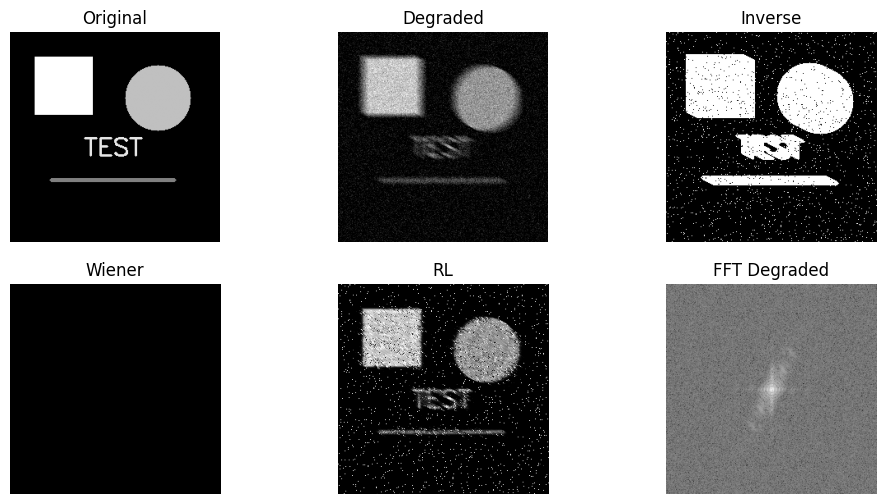

In [ ]:
img = create_image()

# PSF asli & estimasi
psf_true = motion_psf(15,30)
psf_est  = motion_psf(15,30)   # estimasi (bisa diubah)
psf_wrong= motion_psf(10,10)   # PSF salah

# =========================
# DEGRADASI
# =========================
blur = cv2.filter2D(img,-1,psf_true)
gauss = gaussian_noise(blur,20)
sp = salt_pepper(blur,0.05)

datasets = {
    "Blur Only": blur,
    "Gaussian+Blur": gauss,
    "SP+Blur": sp
}

# =========================
# PROSES
# =========================
print("\nHASIL EVALUASI")
print("-"*60)
print(f"{'Skenario':<15}{'Metode':<15}{'PSNR':<10}{'SSIM':<10}{'Waktu':<10}")

for name, data in datasets.items():

    # Inverse
    t=time.time()
    inv = inverse_filter(data, psf_est)
    t1=time.time()-t

    # Wiener
    t=time.time()
    wien = wiener_filter(data, psf_est,0.01)
    t2=time.time()-t

    # RL
    t=time.time()
    rl = richardson_lucy(data, psf_est,10)
    t3=time.time()-t

    for method, img_res, tval in [
        ("Inverse",inv,t1),
        ("Wiener",wien,t2),
        ("RL",rl,t3)
    ]:
        print(f"{name:<15}{method:<15}{psnr(img,img_res):<10.2f}{ssim(img,img_res):<10.2f}{tval:<10.2f}")

# =========================
# PSF ANALISIS
# =========================
print("\nPENGARUH PSF SALAH")
print("-"*40)
wrong = wiener_filter(gauss, psf_wrong)
print("PSNR benar :", psnr(img, wien))
print("PSNR salah :", psnr(img, wrong))

# =========================
# VISUALISASI
# =========================
plt.figure(figsize=(12,6))
imgs = [img, gauss, inv, wien, rl]
titles = ['Original','Degraded','Inverse','Wiener','RL']

for i in range(5):
    plt.subplot(2,3,i+1)
    plt.imshow(imgs[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.subplot(2,3,6)
show_fft(gauss, "FFT Degraded")

plt.show()